In [1]:
from portfolio_functions import *

data, returns = get_data()
returns.tail()

[*********************100%***********************]  3 of 3 completed


Ticker,BND,SPY,TSLA
Date,,,
2026-02-09,0.000269,0.004822,0.015106
2026-02-10,0.002963,-0.002637,0.018906
2026-02-11,-0.002014,-0.000231,0.007196
2026-02-12,0.004575,-0.015449,-0.026152
2026-02-13,0.002947,0.000705,0.000887


In [2]:
tsla_forecast_annual = -0.10824702354318741

mu = expected_returns_calc(returns, tsla_forecast_annual)
print(mu)

Ticker
BND     0.012846
SPY     0.157182
TSLA   -0.108247
dtype: float64


In [3]:
from portfolio_functions import covariance_matrix, plot_covariance
# Assuming your price/returns data is in a variable called 'returns'
cov = covariance_matrix(returns)
# To see the data
cov 

# To run your plot function
plot_covariance(cov)

Saved to: c:\Users\assef\Desktop\Kifiya AI Mastery\week9\Time-Series-Forecasting-for-Portfolio-Management-Optimization\notebooks\task4_portfolio\outputs\covariance_heatmap.png


In [4]:
print(mu)

Ticker
BND     0.012846
SPY     0.157182
TSLA   -0.108247
dtype: float64


In [7]:
# 1. Calculate mu (if you haven't in this cell yet)
mu = returns.mean() * 252

# 2. Call the function with 4 variables matching the 'return' order
sharpe_w, sharpe_perf, minvol_w, minvol_perf = optimize_portfolio(mu, cov)

# 3. Now you can print them correctly
print("--- Maximum Sharpe Portfolio Weights ---")
print(sharpe_w)
print(f"Performance (Return, Vol, Sharpe): {sharpe_perf}")

print("\n--- Minimum Volatility Portfolio Weights ---")
print(minvol_w)
print(f"Performance (Return, Vol, Sharpe): {minvol_perf}")

--- Maximum Sharpe Portfolio Weights ---
OrderedDict({'BND': 0.22089, 'SPY': 0.43175, 'TSLA': 0.34736})
Performance (Return, Vol, Sharpe): (np.float64(0.2989177102530156), np.float64(0.28938415198260864), np.float64(1.0329442998349816))

--- Minimum Volatility Portfolio Weights ---
OrderedDict({'BND': 0.95934, 'SPY': 0.04066, 'TSLA': 0.0})
Performance (Return, Vol, Sharpe): (np.float64(0.01871398033229752), np.float64(0.06553621295697626), np.float64(0.2855517505197169))


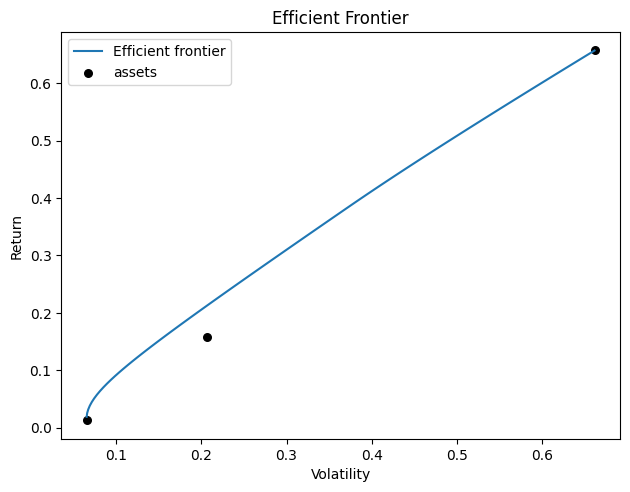

efficient_frontier.png saved ✅


In [8]:
from pypfopt import EfficientFrontier, plotting
import matplotlib.pyplot as plt

ef_plot = EfficientFrontier(mu, cov)

fig, ax = plt.subplots()
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)

plt.title("Efficient Frontier")
plt.savefig("outputs/efficient_frontier.png", bbox_inches="tight")
plt.show()

print("efficient_frontier.png saved ✅")


In [9]:
import pandas as pd

summary = pd.DataFrame({
    "Portfolio": ["Max Sharpe", "Min Vol"],
    "TSLA": [sharpe_w["TSLA"], minvol_w["TSLA"]],
    "BND": [sharpe_w["BND"], minvol_w["BND"]],
    "SPY": [sharpe_w["SPY"], minvol_w["SPY"]],
    "Return": [sharpe_perf[0], minvol_perf[0]],
    "Volatility": [sharpe_perf[1], minvol_perf[1]],
    "Sharpe": [sharpe_perf[2], minvol_perf[2]]
})

summary.to_csv("outputs/portfolio_summary.csv", index=False)

print("portfolio_summary.csv saved ✅")
summary


portfolio_summary.csv saved ✅


,Portfolio,TSLA,BND,SPY,Return,Volatility,Sharpe
0,Max Sharpe,0.34736,0.22089,0.43175,0.298918,0.289384,1.032944
1,Min Vol,0.00000,0.95934,0.04066,0.018714,0.065536,0.285552
